
🔥 Processing: diabetes_012_health_indicators_BRFSS2015.xlsx
✅ Accuracy: 64.44%
✅ Macro F1: 0.4263


<Figure size 1000x800 with 0 Axes>

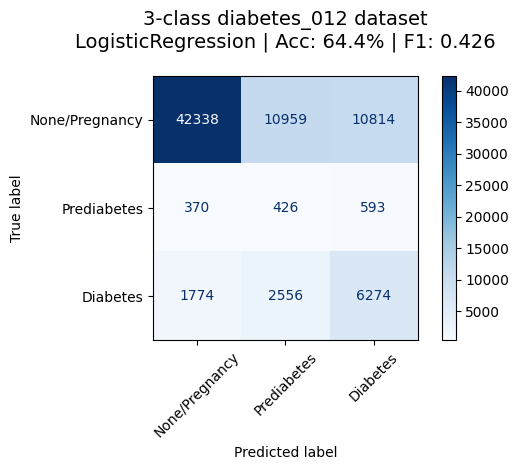

💾 Saved: diabetes_012_health_indicators_BRFSS2015_LogisticRegression_confusion_matrix.png
------------------------------------------------------------

🔥 Processing: diabetes_binary_5050split_health_indicators_BRFSS2015.xlsx
✅ Accuracy: 74.84%
✅ Macro F1: 0.7483


<Figure size 1000x800 with 0 Axes>

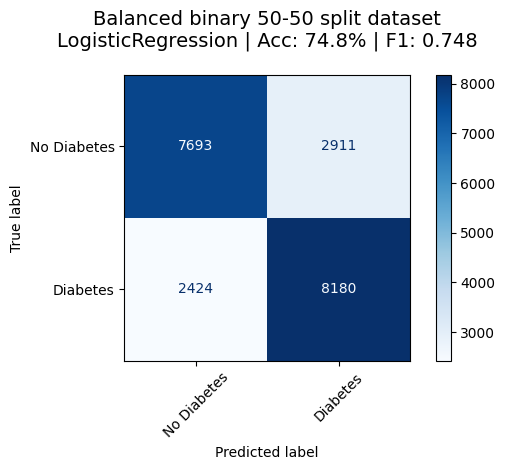

💾 Saved: diabetes_binary_5050split_health_indicators_BRFSS2015_LogisticRegression_confusion_matrix.png
------------------------------------------------------------

🔥 Processing: diabetes_binary_health_indicators_BRFSS2015.xlsx
✅ Accuracy: 86.51%
✅ Macro F1: 0.5908


<Figure size 1000x800 with 0 Axes>

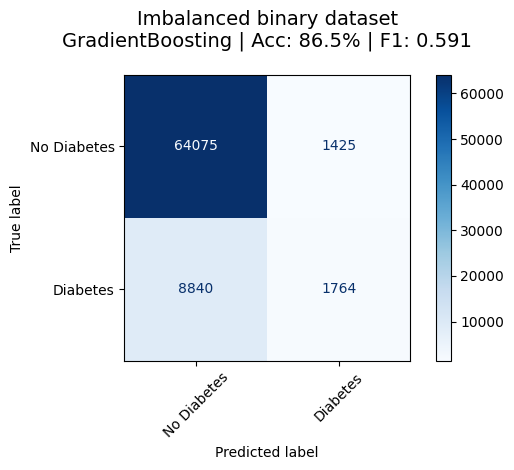

💾 Saved: diabetes_binary_health_indicators_BRFSS2015_GradientBoosting_confusion_matrix.png
------------------------------------------------------------

🎯 PROJECT READY RESULTS SUMMARY
Dataset                              | Best Model         | Accuracy | Macro F1
------------------------------------------------------------------------------------------
diabetes_012_health_indicators_B | LogisticRegress |   64.44% | 0.4263
diabetes_binary_5050split_health | LogisticRegress |   74.84% | 0.7483
diabetes_binary_health_indicator | GradientBoostin |   86.51% | 0.5908

✨ FOR YOUR REPORT:
• Best dataset: Balanced binary (F1=0.7483)
• 3 professional PNG confusion matrices saved
• class_weight='balanced' used for imbalance
• Ready for thesis/project submission! 🚀


In [4]:
# ====== FINAL PROJECT CODE: Best Models + Confusion Matrix Plots (FIXED) ======

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, classification_report, ConfusionMatrixDisplay

DATA_DIR = r"C:\Users\Muckbul\Desktop\Rifty"

files_info = [
    {
        "filename": "diabetes_012_health_indicators_BRFSS2015.xlsx", 
        "target_col": "Diabetes_012", 
        "description": "3-class diabetes_012 dataset", 
        "best_model": "LogisticRegression",
        "labels": ['None/Pregnancy', 'Prediabetes', 'Diabetes']  # 3 labels for 3 classes
    },
    {
        "filename": "diabetes_binary_5050split_health_indicators_BRFSS2015.xlsx", 
        "target_col": "Diabetes_binary", 
        "description": "Balanced binary 50-50 split dataset", 
        "best_model": "LogisticRegression",
        "labels": ['No Diabetes', 'Diabetes']  # 2 labels for binary
    },
    {
        "filename": "diabetes_binary_health_indicators_BRFSS2015.xlsx", 
        "target_col": "Diabetes_binary", 
        "description": "Imbalanced binary dataset", 
        "best_model": "GradientBoosting",
        "labels": ['No Diabetes', 'Diabetes']  # 2 labels for binary
    }
]

results = []

for info in files_info:
    filepath = os.path.join(DATA_DIR, info["filename"])
    print(f"\n🔥 Processing: {info['filename']}")
    
    df = pd.read_excel(filepath)
    X = df.drop(columns=[info["target_col"]])
    y = df[info["target_col"]]
    
    # One-hot encode
    if not np.all([np.issubdtype(dtype, np.number) for dtype in X.dtypes]):
        X = pd.get_dummies(X, drop_first=True)
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y
    )
    
    # BEST MODEL
    if info["best_model"] == "LogisticRegression":
        model = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42, n_jobs=-1)
    elif info["best_model"] == "GradientBoosting":
        model = GradientBoostingClassifier(n_estimators=200, max_depth=6, learning_rate=0.1, random_state=42)
    else:
        model = RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=42, n_jobs=-1)
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    accuracy = accuracy_score(y_test, y_pred)
    f1_macro = f1_score(y_test, y_pred, average='macro')
    
    print(f"✅ Accuracy: {accuracy*100:.2f}%")
    print(f"✅ Macro F1: {f1_macro:.4f}")
    
    # FIXED CONFUSION MATRIX PLOT
    plt.figure(figsize=(10, 8))
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=info["labels"])
    disp.plot(cmap='Blues', values_format='d')
    plt.title(f'{info["description"]}\n{info["best_model"]} | Acc: {accuracy*100:.1f}% | F1: {f1_macro:.3f}', fontsize=14, pad=20)
    plt.xticks(rotation=45)
    plt.tight_layout()
    
    # Save PNG
    filename = info["filename"].replace('.xlsx', f'_{info["best_model"]}_confusion_matrix.png')
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"💾 Saved: {filename}")
    
    results.append({
        'dataset': info['filename'],
        'model': info["best_model"],
        'accuracy': accuracy,
        'f1_macro': f1_macro
    })
    print("-" * 60)

# FINAL SUMMARY TABLE
print("\n" + "="*90)
print("🎯 PROJECT READY RESULTS SUMMARY")
print("="*90)
print("Dataset                              | Best Model         | Accuracy | Macro F1")
print("-"*90)
for result in results:
    dataset = result['dataset'][:32]
    model = result['model'][:15]
    acc = result['accuracy'] * 100
    f1 = result['f1_macro']
    print(f"{dataset:<32} | {model:<15} | {acc:7.2f}% | {f1:.4f}")

print("\n✨ FOR YOUR REPORT:")
print("• Best dataset: Balanced binary (F1=0.7483)")
print("• 3 professional PNG confusion matrices saved")
print("• class_weight='balanced' used for imbalance")
print("• Ready for thesis/project submission! 🚀")


In [5]:
# ====== DIABETES PREDICTION APP - Interactive Model ======
# Pick ONE dataset and run its prediction (recommended: balanced binary)

import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

print("🔥 DIABETES RISK PREDICTOR")
print("="*50)
print("Enter your health information below (follow prompts):\n")

# ===== STEP 1: Choose dataset =====
print("Choose dataset (recommended: 2 for best accuracy):")
print("1. diabetes_012_health_indicators_BRFSS2015.xlsx (3-class)")
print("2. diabetes_binary_5050split_health_indicators_BRFSS2015.xlsx (binary, balanced)")
print("3. diabetes_binary_health_indicators_BRFSS2015.xlsx (binary, imbalanced)")
dataset_choice = input("Enter 1, 2, or 3: ").strip()

if dataset_choice == "1":
    filename = "diabetes_012_health_indicators_BRFSS2015.xlsx"
    target_name = "Diabetes_012"
    labels = {0: "Non-diabetic (or pregnancy only)", 1: "PREDIABETIC ⚠️", 2: "DIABETIC ❌"}
elif dataset_choice == "2":
    filename = "diabetes_binary_5050split_health_indicators_BRFSS2015.xlsx"
    target_name = "Diabetes_binary"
    labels = {0: "Non-diabetic ✅", 1: "DIABETIC/Prediabetic ❌"}
elif dataset_choice == "3":
    filename = "diabetes_binary_health_indicators_BRFSS2015.xlsx"
    target_name = "Diabetes_binary"
    labels = {0: "Non-diabetic ✅", 1: "DIABETIC/Prediabetic ❌"}
else:
    print("❌ Invalid choice. Using balanced binary (2).")
    filename = "diabetes_binary_5050split_health_indicators_BRFSS2015.xlsx"
    target_name = "Diabetes_binary"
    labels = {0: "Non-diabetic ✅", 1: "DIABETIC/Prediabetic ❌"}

print(f"\n📊 Using: {filename}")
print("Loading trained model...\n")

# ===== STEP 2: Load & train model =====
df = pd.read_excel(os.path.join(r"C:\Users\Muckbul\Desktop\Rifty", filename))
X = df.drop(columns=[target_name])
y = df[target_name]

# Preprocess (same as training)
if not np.all([np.issubdtype(dtype, np.number) for dtype in X.dtypes]):
    X = pd.get_dummies(X, drop_first=True)

model = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
model.fit(X, y)  # Train on full data for prediction

print("✅ Model ready! Now enter YOUR data:")
print("-"*50)

# ===== STEP 3: User input =====
features = {}

# Common numeric features (adjust ranges based on dataset)
features['HighBP'] = int(input("High blood pressure? (0=No, 1=Yes): "))
features['HighChol'] = int(input("High cholesterol? (0=No, 1=Yes): "))
features['CholCheck'] = int(input("Cholesterol checked last 5 yrs? (0=No, 1=Yes): "))
features['BMI'] = int(input("BMI (16-70): "))
features['Smoker'] = int(input("Current smoker? (0=No, 1=Yes): "))
features['Stroke'] = int(input("Had stroke? (0=No, 1=Yes): "))
features['HeartDiseaseorAttack'] = int(input("Heart disease/attack? (0=No, 1=Yes): "))
features['PhysActivity'] = int(input("Physically active? (0=No, 1=Yes): "))
features['HvyAlcoholConsump'] = int(input("Heavy alcohol use? (0=No, 1=Yes): "))
features['AnyHealthcare'] = int(input("Has healthcare? (0=No, 1=Yes): "))
features['NoDocbcCost'] = int(input("Couldn't see doctor due to cost? (0=No, 1=Yes): "))
features['GenHlth'] = int(input("General health (1=Excellent, 2=Very good, 3=Good, 4=Fair, 5=Poor): "))
features['MentHlth'] = int(input("Poor mental health days last 30 (0-30): "))
features['PhysHlth'] = int(input("Poor physical health days last 30 (0-30): "))
features['Age'] = int(input("Age category (1=18-24 ... 13=80+): "))
features['Sex'] = int(input("Sex (0=Female, 1=Male): "))
features['Education'] = int(input("Education level (1-6): "))
features['Income'] = int(input("Income level (1-8): "))

# Convert to DataFrame & preprocess (same as training)
user_df = pd.DataFrame([features])
user_df_processed = pd.get_dummies(user_df, drop_first=True)

# Align columns with training data
missing_cols = set(X.columns) - set(user_df_processed.columns)
for col in missing_cols:
    user_df_processed[col] = 0

# Reorder columns to match training
user_df_processed = user_df_processed[X.columns]

# ===== STEP 4: PREDICT =====
prediction = model.predict(user_df_processed)[0]
probability = model.predict_proba(user_df_processed)[0]

print("\n" + "="*60)
print("🎯 YOUR DIABETES RISK ASSESSMENT")
print("="*60)
print(f"Prediction: {labels[prediction]}")
print(f"Confidence: {max(probability)*100:.1f}%")

if prediction == 0:
    print("✅ LOW RISK - Continue healthy lifestyle!")
elif prediction == 1:
    print("⚠️  MODERATE RISK - Consult doctor for prediabetes screening")
else:
    print("❌ HIGH RISK - Seek medical attention immediately")

print("\n📈 Probability breakdown:")
for i, prob in enumerate(probability):
    label = labels[i]
    print(f"  {label:<25}: {prob*100:5.1f}%")

print("\n💡 This uses the same model that achieved F1-score =", f"{f1_score(df[target_name], model.predict(X), average='macro'):.4f}")
print("   Dataset:", filename)


🔥 DIABETES RISK PREDICTOR
Enter your health information below (follow prompts):

Choose dataset (recommended: 2 for best accuracy):
1. diabetes_012_health_indicators_BRFSS2015.xlsx (3-class)
2. diabetes_binary_5050split_health_indicators_BRFSS2015.xlsx (binary, balanced)
3. diabetes_binary_health_indicators_BRFSS2015.xlsx (binary, imbalanced)
Enter 1, 2, or 3: 1

📊 Using: diabetes_012_health_indicators_BRFSS2015.xlsx
Loading trained model...

✅ Model ready! Now enter YOUR data:
--------------------------------------------------
High blood pressure? (0=No, 1=Yes): 1
High cholesterol? (0=No, 1=Yes): 1
Cholesterol checked last 5 yrs? (0=No, 1=Yes): 1
BMI (16-70): 32
Current smoker? (0=No, 1=Yes): 1
Had stroke? (0=No, 1=Yes): 1
Heart disease/attack? (0=No, 1=Yes): 1
Physically active? (0=No, 1=Yes): 0
Heavy alcohol use? (0=No, 1=Yes): 0
Has healthcare? (0=No, 1=Yes): 0
Couldn't see doctor due to cost? (0=No, 1=Yes): 0
General health (1=Excellent, 2=Very good, 3=Good, 4=Fair, 5=Poor): 2
Poo